In [2]:
import pandas as pd
import numpy as np
import pickle as pkl
from xgboost import XGBRegressor
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix




see confusion matrics

In [3]:
df = pd.read_csv("newdataset/train.csv")
df.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [4]:
from sklearn.preprocessing import LabelEncoder

le_dict = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le   # save encoder for test data

C:\Users\kisha\AppData\Local\Temp\ipykernel_33496\3018571655.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [5]:
drop_cols = ["holiday", "school_season", "id", "road_type", "num_lanes", "road_signs_present", "public_road", "time_of_day"]

df.drop(drop_cols, axis=1, inplace=True)

x = df.drop("accident_risk", axis=1)
y = df["accident_risk"]

In [6]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

2. Initialize Model

In [7]:
model=XGBRegressor(
    n_estimators=100,
    Learning_rate=0.1,
    max_depth=5,
    random_state=42
)

train model

In [8]:
model.fit(x_train,y_train)

c:\Users\kisha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:44:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "Learning_rate" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [9]:
y_pred = model.predict(x_test)

In [ ]:
# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("\nClassification Report:\n", classification_report(y_test, y_pred))

ValueError: continuous is not supported

In [10]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 0.0031830743681648507
R2 Score: 0.884722150739989


In [11]:
from sklearn import linear_model

In [12]:
modelli = linear_model.LinearRegression()

In [13]:
modelli.fit(x_train,y_train)

y_pre=model.predict(x_test)

In [14]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pre))
print("R2 Score:", r2_score(y_test, y_pre))

MSE: 0.0031830743681648507
R2 Score: 0.884722150739989


xgboost has higher accuracy than linear model,you cant use cinsusion matrix in regression it will be used in classification 

In [16]:
import matplotlib.pyplot as plt

model.feature_importances_

array([0.17593615, 0.2789343 , 0.40127835, 0.10046367, 0.04338752],
      dtype=float32)

which feature is more important in accident risk

([0, 1, 2, 3, 4],
 [Text(0, 0, 'curvature'),
  Text(1, 0, 'speed_limit'),
  Text(2, 0, 'lighting'),
  Text(3, 0, 'weather'),
  Text(4, 0, 'num_reported_accidents')])

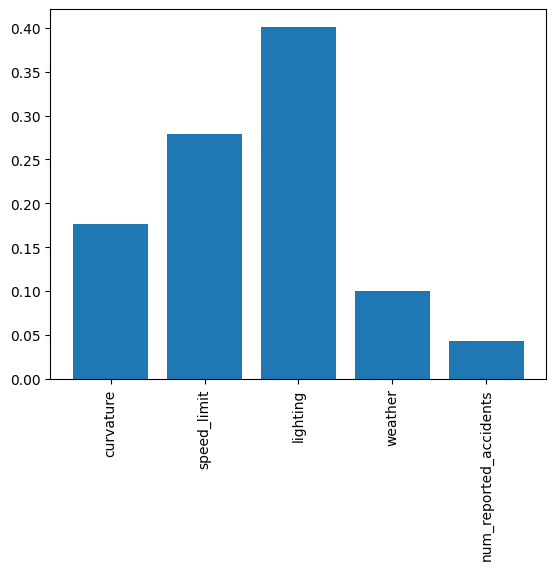

In [17]:
plt.bar(x.columns,model.feature_importances_)
plt.xticks(rotation=90)

In [ ]:
# drop_cols = [
#     "holiday",
#     "school_season",
#      "id",
#   "road_type",
#   "num_lanes",

#   "road_signs_present",
#   "public_road",
#   "time_of_day",
  
  
# ]

# df.drop(drop_cols, axis=1, inplace=True)

KeyError: "['holiday', 'school_season', 'id', 'road_type', 'num_lanes', 'road_signs_present', 'public_road', 'time_of_day'] not found in axis"

In [19]:
import pickle as pkl

pkl.dump(model,open("model/model.pkl","wb"))